In [ ]:
!wget -c http://images.cocodataset.org/zips/val2017.zip
!unzip -q -o val2017.zip

--2026-03-03 12:43:56--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.199.206, 3.5.28.185, 52.216.86.203, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.199.206|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  59.1MB/s    in 14s     

2026-03-03 12:44:11 (54.8 MB/s) - ‘val2017.zip’ saved [815585330/815585330]



**Acquire Dataset (COCO val2017)**

In [ ]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip annotations/instances_val2017.json

--2026-03-03 12:44:20--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.27.143, 54.231.224.217, 16.15.193.235, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.27.143|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  32.9MB/s    in 7.7s    

2026-03-03 12:44:28 (31.2 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]

Archive:  annotations_trainval2017.zip
  inflating: annotations/instances_val2017.json  


**Load COCO and Select Category**

In [ ]:
from pycocotools.coco import COCO

annotation_file = "annotations/instances_val2017.json"
coco = COCO(annotation_file)

cat_ids = coco.getCatIds(catNms=['person'])
img_ids = coco.getImgIds(catIds=cat_ids)

print("Total person images:", len(img_ids))

loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
Total person images: 2693


**Explore Dataset Structure**

In [ ]:
import os
print(len(os.listdir("val2017")))


5000


file_name

height

width

id

In [ ]:
img_info = coco.loadImgs(img_ids[0])[0]
print(img_info)


{'license': 3, 'file_name': '000000532481.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000532481.jpg', 'height': 426, 'width': 640, 'date_captured': '2013-11-20 16:28:24', 'flickr_url': 'http://farm7.staticflickr.com/6048/5915494136_da3cfa7c5a_z.jpg', 'id': 532481}


**Visualize Example Image and Mask**

In [ ]:
import numpy as np

def create_binary_mask(image_id):
    ann_ids = coco.getAnnIds(imgIds=image_id, catIds=cat_ids)
    anns = coco.loadAnns(ann_ids)

    img_info = coco.loadImgs(image_id)[0]
    height, width = img_info['height'], img_info['width']

    mask = np.zeros((height, width))

    for ann in anns:
        mask += coco.annToMask(ann)

    mask = (mask > 0).astype(np.float32)
    return mask


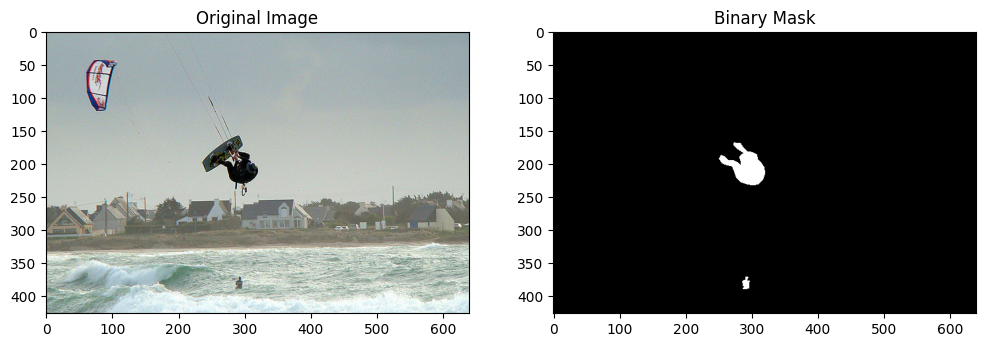

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img_id = img_ids[0]
img_info = coco.loadImgs(img_id)[0]
image = Image.open(f"val2017/{img_info['file_name']}")

mask = create_binary_mask(img_id)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Binary Mask")
plt.imshow(mask, cmap='gray')

plt.show()


**DATA PREPROCESSING & VALIDATION** ****
Develop Preprocessing Pipeline

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

*Ensure Image–Mask Alignment**
Image and mask must undergo same resize.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class CocoSegmentationDataset(Dataset):
    def __init__(self, img_ids, image_dir, transform=None):
        self.img_ids = img_ids
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = coco.loadImgs(img_id)[0]

        image = Image.open(f"{self.image_dir}/{img_info['file_name']}").convert("RGB")
        mask = create_binary_mask(img_id)

        mask = Image.fromarray((mask * 255).astype(np.uint8))

        if self.transform:
            image = self.transform(image)
            mask = transforms.Resize((256,256))(mask)
            mask = transforms.ToTensor()(mask)

        return image, mask

**Shuffle and Split (70/15/15)**

In [ ]:
import random

random.seed(42)
random.shuffle(img_ids)

total = len(img_ids)
train_split = int(0.7 * total)
val_split = int(0.15 * total)

train_ids = img_ids[:train_split]
val_ids = img_ids[train_split:train_split+val_split]
test_ids = img_ids[train_split+val_split:]

**Create DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

train_dataset = CocoSegmentationDataset(train_ids, "val2017", transform)
val_dataset = CocoSegmentationDataset(val_ids, "val2017", transform)
test_dataset = CocoSegmentationDataset(test_ids, "val2017", transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

**Verify Alignment Visually**

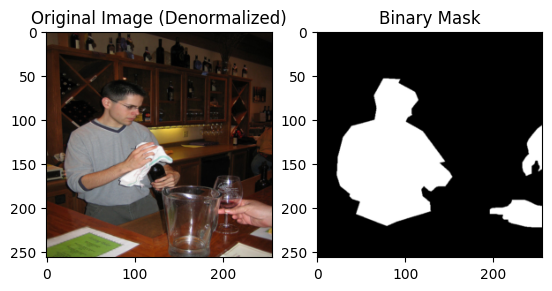

In [ ]:
import torch

image, mask = train_dataset[0]

# Denormalize image for plotting
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
image_denormalized = image * std + mean
image_denormalized = torch.clamp(image_denormalized, 0, 1) # Ensure values are within [0, 1]

plt.subplot(1,2,1)
plt.imshow(image_denormalized.permute(1,2,0))
plt.title("Original Image (Denormalized)")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Binary Mask")

plt.show()

Install Required Libraries

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
from PIL import Image

Create U-Net Model


In [ ]:
import segmentation_models_pytorch as smp
import torch

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.cuda()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Loss Function & Optimizer


In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

dice_loss = smp.losses.DiceLoss(
    mode="binary"
)

def combined_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training Loop Setup

In [ ]:
epochs = 5

for epoch in range(epochs):

    # ===== TRAINING =====
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):
        images = images.cuda()
        masks = masks.cuda()

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.cuda()
            masks = masks.cuda()

            outputs = model(images)

            loss = combined_loss(outputs, masks)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 30)

100%|██████████| 472/472 [00:58<00:00,  8.11it/s]


Epoch 1/5
Train Loss: 1.0536
Val Loss:   0.9737
------------------------------


100%|██████████| 472/472 [00:55<00:00,  8.54it/s]


Epoch 2/5
Train Loss: 0.9476
Val Loss:   0.9366
------------------------------


100%|██████████| 472/472 [00:53<00:00,  8.76it/s]


Epoch 3/5
Train Loss: 0.9022
Val Loss:   0.8464
------------------------------


100%|██████████| 472/472 [00:53<00:00,  8.74it/s]


Epoch 4/5
Train Loss: 0.8584
Val Loss:   0.7607
------------------------------


100%|██████████| 472/472 [00:54<00:00,  8.70it/s]


Epoch 5/5
Train Loss: 0.8071
Val Loss:   0.7820
------------------------------


Visualize Early Predictions to Verify Subject Extraction


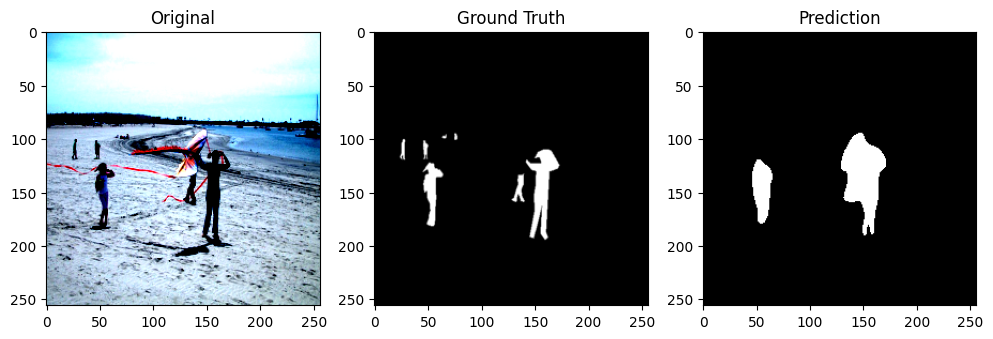

In [ ]:
model.eval()

with torch.no_grad():
    image, mask = val_dataset[0]
    image_input = image.unsqueeze(0).cuda()

    output = model(image_input)
    output = torch.sigmoid(output)
    pred_mask = (output > 0.5).float()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred_mask.squeeze().cpu(), cmap='gray')

plt.show()

Generate Predictions on the Validation Set


In [ ]:
model.eval()

all_preds = []
all_masks = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.cuda()
        masks = masks.cuda()

        outputs = model(images)
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float()

        all_preds.append(preds)
        all_masks.append(masks)

Compute IoU Metric

In [ ]:
def iou_score(pred, target):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

iou_total = 0
count = 0

for preds, masks in zip(all_preds, all_masks):
    iou_total += iou_score(preds, masks)
    count += 1

print("Average IoU:", (iou_total / count).item())

Average IoU: 0.4563146233558655


Hyperparameter Tuning

In [ ]:
#Learning Rate
lr = 1e-3
lr = 1e-5
#Batch Size
batch_size = 8
#Number of Epochs
epochs = 10

Add Data Augmentation

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Overlay Prediction

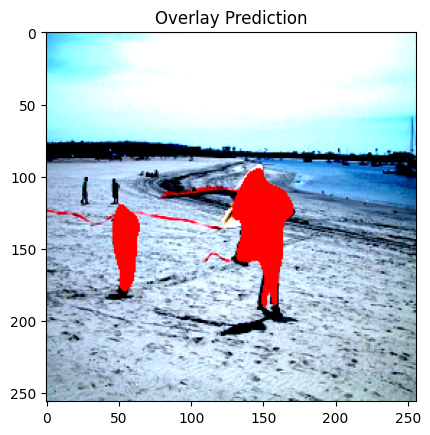

In [ ]:
image_np = image.permute(1,2,0).cpu().numpy()
mask_np = pred_mask.squeeze().cpu().numpy()

overlay = image_np.copy()
overlay[mask_np == 1] = [1, 0, 0]

plt.imshow(overlay)
plt.title("Overlay Prediction")
plt.show()